<a href="https://colab.research.google.com/github/a-nrgl/yzta/blob/main/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bilişsel Performans Skoru Tahmini

Bu notebookta bireylerin uyku düzeni, yaşam alışkanlıkları ve günlük durumlarına ait değişkenler kullanılarak bilişsel performans skorunun tahmin edilmesi amaçlanmaktadır.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Veri Yükleme ve Ortam Hazırlığı

In [4]:
!unzip -o "/content/drive/MyDrive/yzta/yzta-2026-datathon.zip" -d "/content/drive/MyDrive/yzta/"

Archive:  /content/drive/MyDrive/yzta/yzta-2026-datathon.zip
  inflating: /content/drive/MyDrive/yzta/sample_submission.csv  
  inflating: /content/drive/MyDrive/yzta/test_x.csv  
  inflating: /content/drive/MyDrive/yzta/train.csv  


In [6]:
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/yzta/"

train = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test_x.csv")
sample_submission = pd.read_csv(path + "sample_submission.csv")

## Keşifsel Veri Analizi (EDA) ve Train-Test Tutarlılık Kontrolü

In [ ]:
#shape
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape) #submission shape (24000,2) olmalı

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

Eğitim ve test veri setleri; değişken türleri ve eksik gözlem dağılımları açısından birbiriyle uyumlu.

In [ ]:
train_meslekler = set(train["meslek"].dropna().unique())
test_meslekler = set(test["meslek"].dropna().unique())
sadece_test_meslekler = test_meslekler.difference(train_meslekler)
sadece_test_meslekler


set()

 Set() çıktısı Test verisinde olan mesleklerin train verisinde de olduğunu gösteriyor.

In [ ]:
train.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [ ]:
test.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


In [ ]:
# id kontrolü
print("Train tekrar eden id sayısı:", train["id"].duplicated().sum())
print("Test tekrar eden id sayısı:", test["id"].duplicated().sum())

Train tekrar eden id sayısı: 0
Test tekrar eden id sayısı: 0


In [ ]:
train.describe()


,id,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,bilissel_performans_skoru
count,56000.000000,56000.000000,54248.000000,56000.000000,56000.000000,56000.000000,56000.000000,54537.000000,56000.000000,56000.000000,56000.000000,54285.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,28000.500000,34.714446,26.273651,20.233500,20.246063,20.107536,3.344929,42.110952,63.511446,7493.197554,15.432875,5.741407,7.156456,66.603214,20.531263,1.199050,5.913096
std,16165.951874,11.052508,4.495138,3.442993,4.300421,8.063278,2.034618,72.154159,44.590737,3462.699361,21.104672,1.624985,3.469731,7.353174,2.903317,0.790899,2.231759
min,1.000000,18.000000,16.000000,10.000000,5.000000,1.000000,0.000000,0.000000,2.000000,500.000000,0.000000,1.000000,0.000000,45.000000,15.000000,-1.000000,0.000000
25%,14000.750000,26.000000,23.175279,17.951724,17.337866,14.000000,2.000000,0.000000,30.000000,5042.000000,0.000000,4.761271,4.765942,62.000000,18.457240,0.660030,4.397431
50%,28000.500000,33.000000,26.225806,20.302218,20.292151,20.000000,3.000000,3.000000,51.000000,7426.000000,2.000000,5.824014,7.360860,67.000000,20.487456,1.202921,6.032249
75%,42000.250000,42.000000,29.321503,22.598180,23.227117,25.000000,5.000000,77.000000,84.000000,9876.000000,30.000000,6.837436,9.684531,72.000000,22.522152,1.743940,7.574980
max,56000.000000,69.000000,45.000000,30.000000,30.000000,58.000000,8.000000,400.000000,180.000000,20000.000000,115.000000,10.000000,18.000000,97.000000,28.000000,3.000000,10.000000


In [ ]:
test.describe()

,id,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat
count,24000.000000,24000.000000,23352.000000,24000.000000,24000.000000,24000.000000,24000.000000,23303.000000,24000.000000,24000.000000,24000.000000,23235.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,12000.500000,34.662125,26.354491,20.278214,20.292365,20.063833,3.354333,42.361885,63.516167,7516.762917,15.322667,5.723828,7.123312,66.515250,20.537667,1.198398
std,6928.347566,11.044303,4.455273,3.424471,4.258140,8.050903,2.027610,72.477832,44.338866,3462.578765,21.115702,1.635602,3.504064,7.388835,2.896022,0.787499
min,1.000000,18.000000,16.000000,10.000000,5.000000,1.000000,0.000000,0.000000,2.000000,500.000000,0.000000,1.000000,0.000000,45.000000,15.000000,-1.000000
25%,6000.750000,26.000000,23.317409,17.976686,17.425478,14.000000,2.000000,0.000000,30.000000,5045.750000,0.000000,4.750390,4.696461,62.000000,18.488856,0.666372
50%,12000.500000,33.000000,26.351529,20.332256,20.385155,20.000000,3.000000,3.000000,51.000000,7485.000000,2.000000,5.817449,7.343444,67.000000,20.502743,1.195771
75%,18000.250000,42.000000,29.397719,22.636045,23.235841,25.000000,5.000000,77.000000,84.000000,9946.000000,30.000000,6.812806,9.686928,71.000000,22.522040,1.739154
max,24000.000000,69.000000,42.679050,30.000000,30.000000,58.000000,8.000000,400.000000,180.000000,20000.000000,112.000000,10.000000,18.000000,95.000000,28.000000,3.000000


Train ve test setindeki veriler uyumlu gözükmektedir.

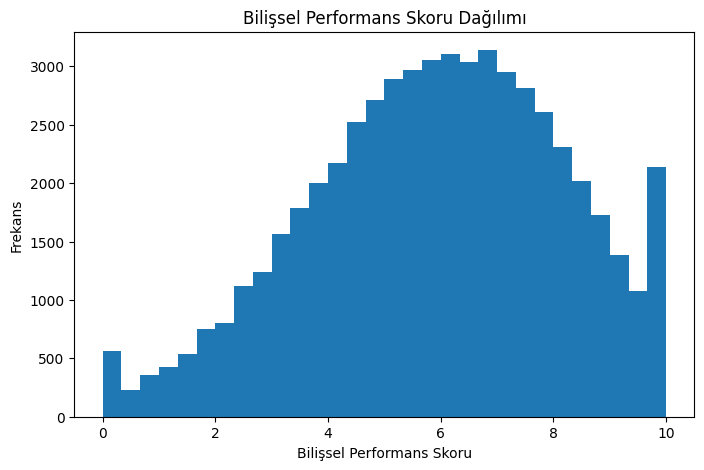

In [8]:
import matplotlib.pyplot as plt

#hedef değişkenin histogram ile gösterilmesi

target = "bilissel_performans_skoru"

plt.figure(figsize=(8, 5))
plt.hist(train[target], bins=30)
plt.xlabel("Bilişsel Performans Skoru")
plt.ylabel("Frekans")
plt.title("Bilişsel Performans Skoru Dağılımı")
plt.show()

Model düşük performans gösteren kişileri tahmin ederken zorlanabilir.

In [ ]:

skor_araliklari = pd.cut(
    train[target],
    bins=[0,1,2,3,4,5,6,7,8,9,10],
    include_lowest=True)

skor_dagilimi_df = pd.DataFrame({

    "count": skor_araliklari.value_counts().sort_index(),

    "oran_%": skor_araliklari.value_counts(normalize=True).sort_index() * 100})

skor_dagilimi_df

,count,oran_%
bilissel_performans_skoru,,
"(-0.001, 1.0]",1150,2.053571
"(1.0, 2.0]",1707,3.048214
"(2.0, 3.0]",3155,5.633929
"(3.0, 4.0]",5353,9.558929
"(4.0, 5.0]",7406,13.225000
"(5.0, 6.0]",8918,15.925000
"(6.0, 7.0]",9281,16.573214
"(7.0, 8.0]",8374,14.953571
"(8.0, 9.0]",6056,10.814286


Düşük skor grupları daha az temsil edilmektedir; 0–1 aralığı yalnızca %2.05, 1–2 aralığı ise %3.05 oranındadır. Bu nedenle modelin düşük bilişsel performans skorlarını tahmin ederken daha zorlanabileceği dikkate alınmalıdır.

In [9]:
#Sayısal değişkenlerin target(bilişsel performans skoru) ile korelasyonu

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["id", target]]

corr_target = train[numeric_cols + [target]].corr()[target].sort_values(ascending=False)

corr_target

,bilissel_performans_skoru
bilissel_performans_skoru,1.000000
rem_yuzdesi,0.442999
derin_uyku_yuzdesi,0.280006
gunluk_adim_sayisi,0.134042
hafta_sonu_uyku_farki_saat,-0.001648
oda_sicakligi_celsius,-0.011992
sekerleme_suresi_dk,-0.023683
vucut_kitle_indeksi,-0.037990
uyku_oncesi_ekran_suresi_dk,-0.044631
uyku_oncesi_kafein_mg,-0.062387


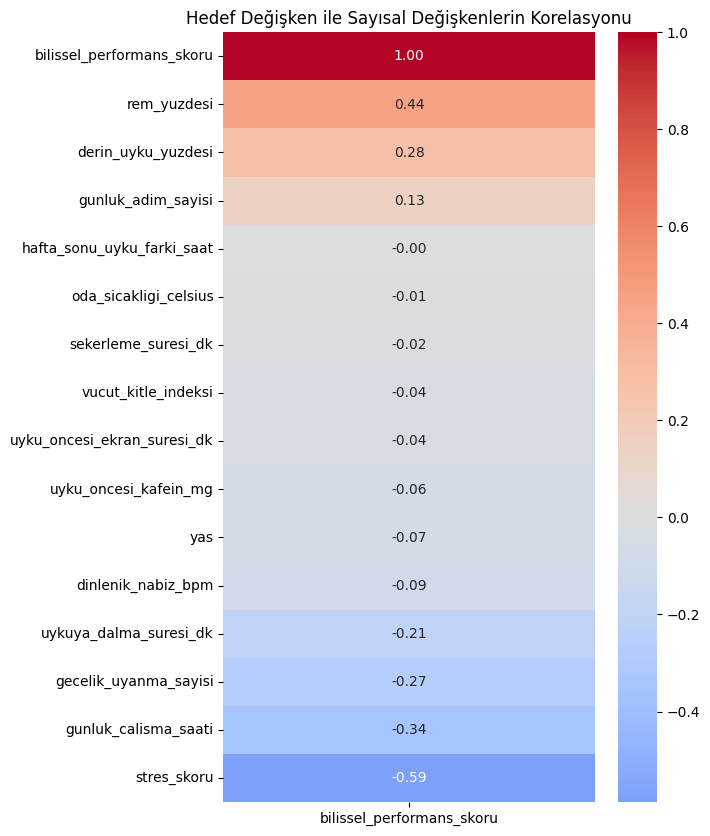

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_target,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Hedef Değişken ile Sayısal Değişkenlerin Korelasyonu")
plt.show()

Sayısal değişkenlerin hedef değişken ile korelasyonu incelendiğinde, `stres_skoru` değişkeninin bilişsel performans skoru ile en güçlü negatif ilişkiye sahip olduğu görülmektedir (-0.59). Bu durum stres düzeyi arttıkça bilişsel performans skorunun düşme eğiliminde olduğunu göstermektedir.

Pozitif yönde en güçlü ilişki `rem_yuzdesi` değişkeninde görülmektedir (0.44). Ayrıca `derin_uyku_yuzdesi` de hedef değişkenle pozitif ilişkilidir (0.28). Bu sonuç, uyku kalitesine ilişkin değişkenlerin bilişsel performans üzerinde önemli olabileceğini düşündürmektedir.

Negatif yönde dikkat çeken diğer değişkenler `gunluk_calisma_saati` (-0.34), `gecelik_uyanma_sayisi` (-0.27) ve `uykuya_dalma_suresi_dk` (-0.21) olmuştur. Bu değişkenler arttıkça bilişsel performans skorunun azalma eğiliminde olduğu gözlenmektedir.

Buna karşılık `hafta_sonu_uyku_farki_saat` ve `oda_sicakligi_celsius` değişkenlerinin hedef değişkenle doğrusal korelasyonu oldukça düşüktür. Ancak korelasyon doğrusal ilişkiyi ölçtüğü için **özellikle oda sıcaklığının doğrusal olmayan bir etkisi olabileceğinden modelleme aşamasında ayrıca değerlendirilmelidir.**

In [ ]:
#kategorik değişkenlerin target(bilişsel performans skoru)ile ilişkisi

categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    display(
        train.groupby(col)[target]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )


cinsiyet


,count,mean,median
cinsiyet,,,
Erkek,27324,5.913804,6.02978
Kadin,28676,5.912420,6.03498



meslek


,count,mean,median
meslek,,,
Emekli,3778,7.935044,8.140140
Ev Hanimi,3224,7.055969,7.234872
Serbest Calisan,3812,6.985534,7.200061
Egitimci,4395,6.343725,6.506638
Muhendis,6533,6.223087,6.327394
Satis ve Pazarlama Calisani,3899,6.010286,6.147973
Yonetici,4454,5.729820,5.781396
Ogrenci,8132,5.535248,5.601813
Lojistik Calisani,3811,5.119135,5.218837



ulke


...

,count,mean,median
ruh_sagligi_durumu,,,
Saglikli,38365,6.491822,6.621904
Anksiyete,8270,5.012262,5.093158
Depresyon,5504,4.394400,4.509263
Anksiyete ve depresyon,2765,3.590186,3.613890



mevsim


,count,mean,median
mevsim,,,
Sonbahar-Kis,27857,5.915958,6.026709
Ilkbahar-Yaz,28143,5.910262,6.040667



gun_tipi


,count,mean,median
gun_tipi,,,
Hafta sonu,15948,6.993307,7.216302
Hafta ici,40052,5.482975,5.542429


**Cinsiyet** değişkeninin hedef değişken üzerinde tek başına güçlü bir ayırt edici etkisi olmadığı düşünülmektedir.

**Meslek** değişkenine göre bilişsel performans skorlarında belirgin farklılıklar görülmektedir. En yüksek ortalama skor `Emekli`, `Ev Hanimi` ve `Serbest Calisan` gruplarında; en düşük ortalama skorlar ise `Lawyer`, `Saglik Personeli` ve `Lojistik Calisani` gruplarında gözlenmiştir. Bu durum `meslek` değişkeninin hedef değişkenle ilişkili olabileceğini düşündürmektedir. Ancak bu farklar doğrudan meslekten değil; stres düzeyi, çalışma saati ve uyku düzeni gibi meslekle ilişkili diğer değişkenlerden de kaynaklanabilir.

**Bazı ülkelerin farklı dillerde görülmektedir. Örneğin `Spain` ve `Ispanya`, `Sweden` ve `Isvec`, `South Korea` ve `Guney Kore`. Bu durum modelleme aşamasında aynı kategorinin farklı sınıflar gibi değerlendirilmesine neden olabilir. Bu nedenle ülke isimlerinin standartlaştırılması değerlendirilmelidir.**

**Kronotip** grupları arasında küçük bir fark var. Bu değişken modelde katkı sağlayabilir ama tek başına güçlü bir ayırıcı gibi görünmüyor.

**Ruh sağlığı durumu** değişkenine göre bilişsel performans skorlarında belirgin farklılıklar görülmektedir. `Saglikli` grubunda ortalama skor en yüksekken, `Anksiyete`, `Depresyon` ve özellikle `Anksiyete ve depresyon` gruplarında ortalama skor belirgin biçimde düşmektedir. Bu durum ruh sağlığı durumunun bilişsel performans skoru ile güçlü ilişkili olabileceğini göstermektedir.

**Mevsim** değişkeninin tek başına hedef değişkeni ayırmada güçlü bir etkisi olmadığı gözükmektedir.

**Gün tipi** değişkeninde hafta sonu ortalama skor yaklaşık 6.99 iken, hafta içi ortalama skor yaklaşık 5.48’dir. Bu fark, hafta sonu gözlemlerinin daha yüksek bilişsel performans skorlarıyla ilişkili olabileceğini göstermektedir. Ancak bu durum doğrudan gün tipinden kaynaklanıyor olmayabilir; hafta sonlarında çalışma saati, stres düzeyi, uyku düzeni veya dinlenme süresi gibi değişkenlerin farklılaşması da bu sonucu etkileyebilir.

In [ ]:
train["ulke"].value_counts()

,count
ulke,
Ingiltere,11324
Cin,9989
Guney Kore,4459
Amerika,4447
Arjantin,3973
Fransa,3440
Ispanya,2823
Isvec,2798
Yeni Zelanda,2777


In [ ]:
# Aynı ülkeyi ifade eden farklı yazımları tek kategori altında birleştirme
ulke_map = {
    "Spain": "Ispanya",
    "Sweden": "Isvec",
    "South Korea": "Guney Kore"
}

train["ulke"] = train["ulke"].replace(ulke_map)
test["ulke"] = test["ulke"].replace(ulke_map)

In [ ]:
train["ulke"].value_counts()

,count
ulke,
Ingiltere,11324
Cin,9989
Guney Kore,6648
Amerika,4447
Arjantin,3973
Ispanya,3962
Fransa,3440
Isvec,3364
Yeni Zelanda,2777


In [ ]:
#### Hafta Sonu Performans Artışını Açıklayabilecek Değişkenlerin İncelenmesi

train.groupby("gun_tipi")[["stres_skoru", "gunluk_calisma_saati", "uykuya_dalma_suresi_dk", "gecelik_uyanma_sayisi"]].mean()

,stres_skoru,gunluk_calisma_saati,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi
gun_tipi,,,,
Hafta ici,5.913429,7.961914,20.215120,3.373789
Hafta sonu,5.309561,5.133620,19.837346,3.272448


Bu bulgu, hafta sonu bilişsel performans skorunun daha yüksek olmasının yalnızca gün tipinden değil; daha düşük stres düzeyi ve daha az çalışma yükü gibi faktörlerden kaynaklanabileceğini göstermiştir.

## Outlier / Aykırı Değer Analizi

In [10]:
outlier_summary = []

for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = train[(train[col] < lower_bound) | (train[col] > upper_bound)].shape[0]
    outlier_ratio = outlier_count / train.shape[0] * 100

    outlier_summary.append({
        "degisken": col,
        "alt_sinir": lower_bound,
        "ust_sinir": upper_bound,
        "aykiri_deger_sayisi": outlier_count,
        "oran_%": outlier_ratio
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df["oran_%"] = outlier_summary_df["oran_%"].round(2)

outlier_summary_df.sort_values("aykiri_deger_sayisi", ascending=False)

,degisken,alt_sinir,ust_sinir,aykiri_deger_sayisi,oran_%
6,uyku_oncesi_kafein_mg,-115.500000,192.500000,3360,6.00
7,uyku_oncesi_ekran_suresi_dk,-51.000000,165.000000,3290,5.88
10,stres_skoru,1.647023,9.951683,986,1.76
4,uykuya_dalma_suresi_dk,-2.500000,41.500000,531,0.95
9,sekerleme_suresi_dk,-45.000000,75.000000,505,0.90
2,rem_yuzdesi,10.982040,29.567864,420,0.75
12,dinlenik_nabiz_bpm,47.000000,87.000000,300,0.54
3,derin_uyku_yuzdesi,8.503989,32.060993,235,0.42
0,yas,2.000000,66.000000,184,0.33
1,vucut_kitle_indeksi,13.955942,38.540840,173,0.31


IQR yöntemi ile yapılan aykırı değer analizinde en yüksek aykırı değer oranları `uyku_oncesi_kafein_mg` (%6.00) ve `uyku_oncesi_ekran_suresi_dk` (%5.88) değişkenlerinde görülmüştür. Bununla birlikte bu değişkenlerdeki yüksek değerler gerçek yaşam koşullarında mümkün olabileceğinden doğrudan **problemli veri olarak değerlendirilmemiştir.** Benzer şekilde stres skoru, uykuya dalma süresi ve şekerleme süresi değişkenlerinde de IQR’ye göre aykırı değerler bulunmasına rağmen bu değerler değişkenlerin doğal dağılımı ve anlamı dikkate alınarak korunmuştur. **Bu aşamada verilere müdahale edilmemiştir.**